# Introduction to Machine Learning and classifiers

In this practical session we will cover:
- The most common classifiers (kNN, SVM, decision trees, ensembles, Naive Bayes, ...) and how to evaluate them (confusion matrix, classification report, accuracy).
- The basics of Bayes' rule and how per-class feature distributions relate to classifier performance.
- K-means clustering, implemented from scratch.
- The fundamentals of logistic regression (the basic building block behind neural networks), including how to derive and implement its gradient-descent optimization.

## (1) Check and understand the code below, discuss the results.
(1.a) Explain how K-Nearest Neighbors (KNN) and Naive Bayes work. (It's ok for now if you don't fully understand the rest of the methods below, we will see them later.)

*Follow-up:* K-means, despite the similar name, is a different, unrelated algorithm: it's a **clustering** method (unsupervised, no labels) rather than a classifier like KNN (supervised, uses labels). Briefly explain how K-means differs from KNN — we will implement K-means from scratch in Exercise 3.

(1.b) What is the role of the scaler? Why is that needed or important?

(1.c) What is the role of the train_test_split function? Why is that needed or important?

(1.d) What is the confusion_matrix and what information does it provide?

(1.e) What is the role of the classification_report function?

(1.f) What is the role of the accuracy_score function? When this metric might not be the best option?

### **(1.a) KNN, Naive Bayes & K-means**
**KNN (Supervised):** Finds $k$ closest training points to new sample using distance (e.g. Euclidean). Assigns majority class label.

**Naive Bayes (Supervised):** Uses Bayes' Theorem to find highest probability class: $P(y|X) \propto P(y) \prod P(x_i|y)$. Assumes all features conditionally independent given class.

**K-means vs KNN:**
**KNN:** Supervised classification. Uses labeled data. No training phase; finds neighbors at query time.
**K-means:** Unsupervised clustering. No labels. Iteratively updates $K$ cluster centroids to group similar data.

### **(1.b) Role of Scaler**
Standardizes feature ranges (e.g. mean=0, std=1 or min-max).
Essential for distance-based models (KNN, SVM) so large-magnitude features do not dominate distance calculations.

### **(1.c) Role of train_test_split**
Splits data into separate sets: train to fit model, test to evaluate.
Prevents data leakage and measures generalization on unseen data (detects overfitting).

### **(1.d) Confusion Matrix**
2D table comparing actual vs. predicted classes.
Shows True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) to reveal specific error types per class.

### **(1.e) Role of classification_report**
Computes key classification metrics per class and macro/weighted averages:
Precision: $\frac{TP}{TP + FP}$
Recall: $\frac{TP}{TP + FN}$
F1-Score: Harmonic mean of precision and recall.
Support: Count of true instances per class.

### **(1.f) Role of accuracy_score & Limitations**
Role: Fraction of correct predictions: $\frac{TP + TN}{\text{Total}}$.
When bad: Imbalanced datasets (e.g., 99% Class A, 1% Class B). A trivial model predicting always Class A gives 99% accuracy but fails minority class completely. Use F1-score, balanced accuracy, or ROC-AUC instead.

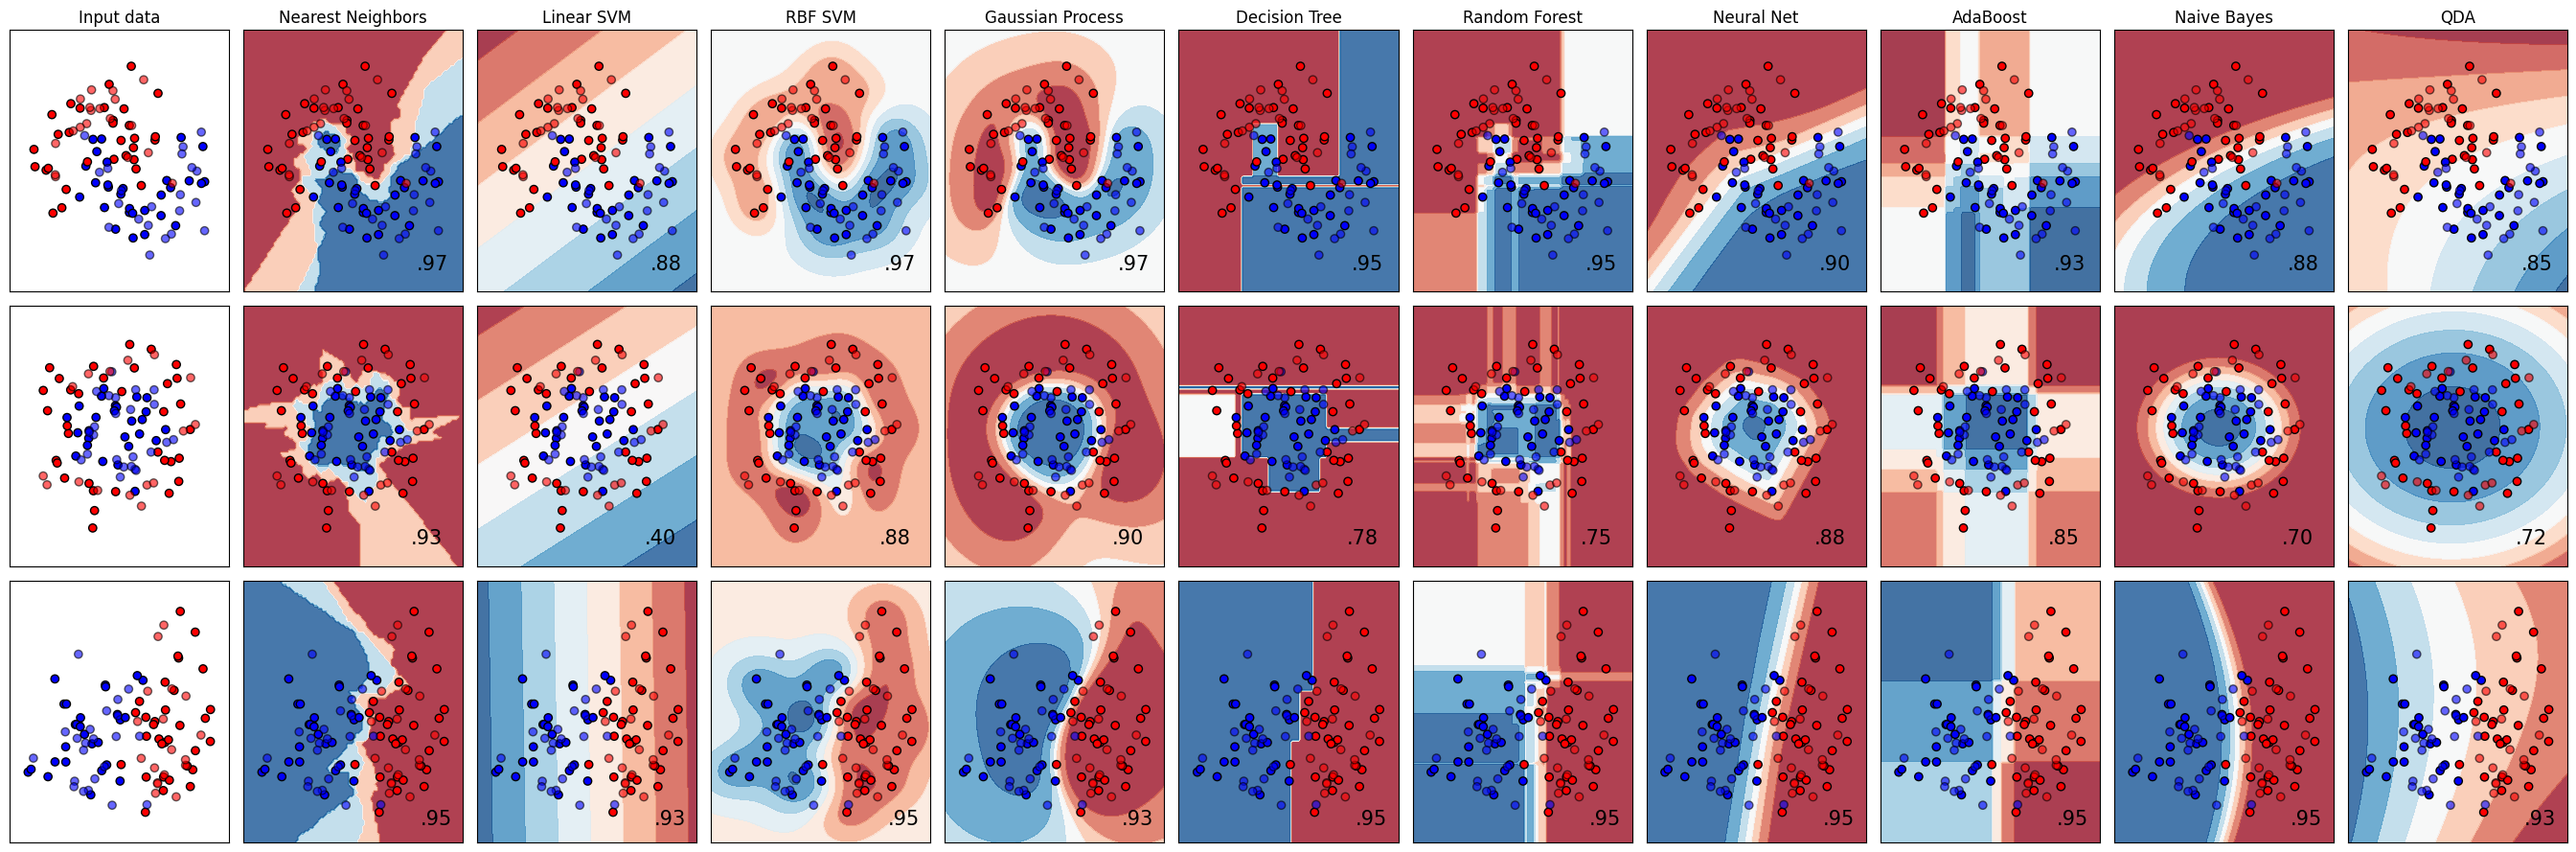

Confusion matrix (Random Forest, moons dataset):
[[18  1]
 [ 1 20]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      0.95      0.95        21

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40


Accuracy: 0.950


In [1]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# Adapted by Matias Di Martino
# License: BSD 3 clause

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

np.random.seed(0)

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(algorithm="SAMME", random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

# Compute detailed metrics for one classifier on one dataset, to give a concrete referent for
# questions (1.d)-(1.f) below: confusion matrix, classification report, and accuracy score.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X, y = datasets[0]  # moons dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
clf = make_pipeline(
    StandardScaler(), RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=42)
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Confusion matrix (Random Forest, moons dataset):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")

## (2) Reviewing PDFs and Bayes concepts
(2.a) For the datasets defined above, plot each dimension (X1 and X2) 1D distribution.

(2.b) Discuss if we only had X1 or X2 values, how would you expect Bayes classifier to perform?

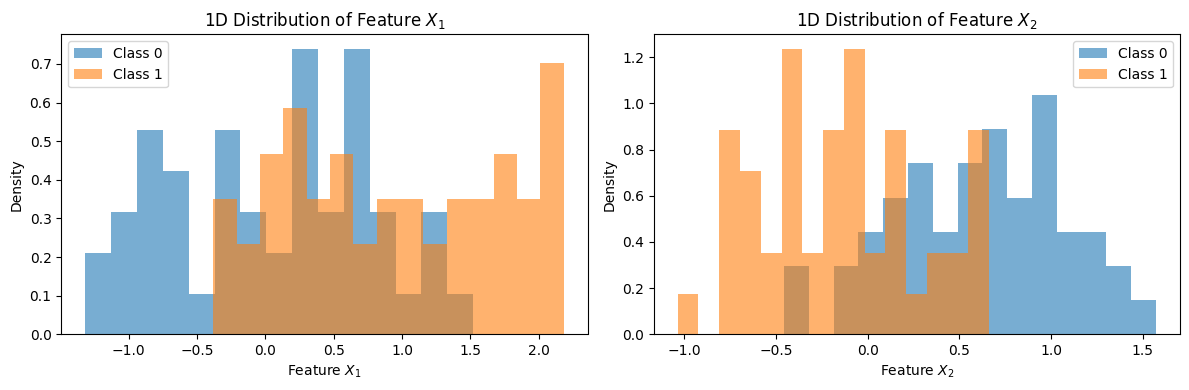

In [5]:
# Ex 2(a): plot the per-class 1D distribution of each feature (X1, X2), for one of the datasets
# defined above.
X, y = datasets[0]  # moons dataset -- feel free to also try datasets[1]/datasets[2]

# TODO: your code here

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for feature_idx, (ax, feat_name) in enumerate(zip(axes, ["Feature $X_1$", "Feature $X_2$"])):
    for label in np.unique(y):
        ax.hist(
            X[y == label, feature_idx],
            bins=15,
            density=True,
            alpha=0.6,
            label=f"Class {label}",
        )
    ax.set_title(f"1D Distribution of {feat_name}")
    ax.set_xlabel(feat_name)
    ax.set_ylabel("Density")
    ax.legend()
plt.tight_layout()
plt.show()

## (3) K-means
(3.a) Implement K-means algorithm from scratch, and compare it with sklearn implementation (it's ok if your algorithm is slower).

(3.b) Explore the performance for different values of K and optimize this parameter. Discuss how to optimize K. 

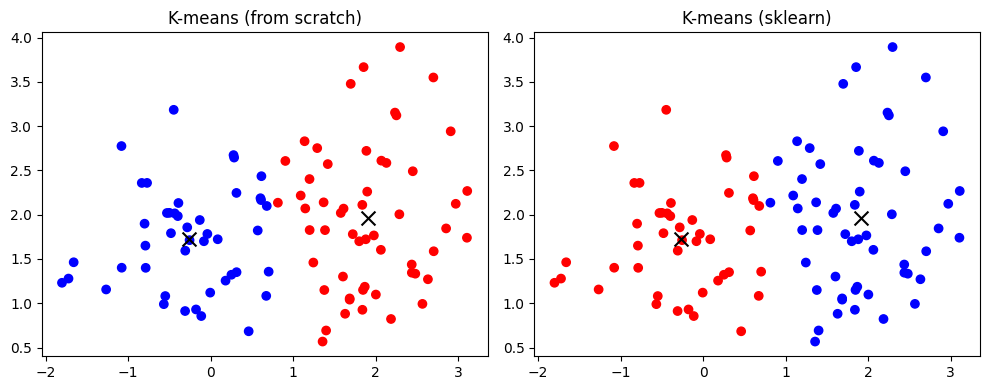

In [7]:
# Ex 3(a): implement K-means from scratch (init, assign, update loop) and compare it with
# sklearn's implementation below (it's ok if ours is slower).
# implement: def kmeans(X, k, n_iters=100) -> (centroids, labels)
# TODO: your code here

def kmeans(X, k, n_iters=100):
    np.random.seed(0)
    # 1. Initialize centroids randomly from data points
    idx = np.random.choice(len(X), size=k, replace=False)
    centroids = X[idx].copy()
    for _ in range(n_iters):
        # 2. Assign labels based on closest centroid (Euclidean distance)
        # distances shape: (N, k)
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        # 3. Update centroids to mean of assigned points
        new_centroids = np.array(
            [
                X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
                for i in range(k)
            ]
        )
        # Early stop if converged
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return centroids, labels

# Compare our from-scratch K-means with sklearn's implementation, on the linearly-separable data
from sklearn.cluster import KMeans

X, y = linearly_separable
k = 2
centroids, labels = kmeans(X, k)
sk_kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap=cm_bright)
axes[0].scatter(centroids[:, 0], centroids[:, 1], c="black", marker="x", s=100)
axes[0].set_title("K-means (from scratch)")
axes[1].scatter(X[:, 0], X[:, 1], c=sk_kmeans.labels_, cmap=cm_bright)
axes[1].scatter(sk_kmeans.cluster_centers_[:, 0], sk_kmeans.cluster_centers_[:, 1], c="black", marker="x", s=100)
axes[1].set_title("K-means (sklearn)")
plt.tight_layout()
plt.show()

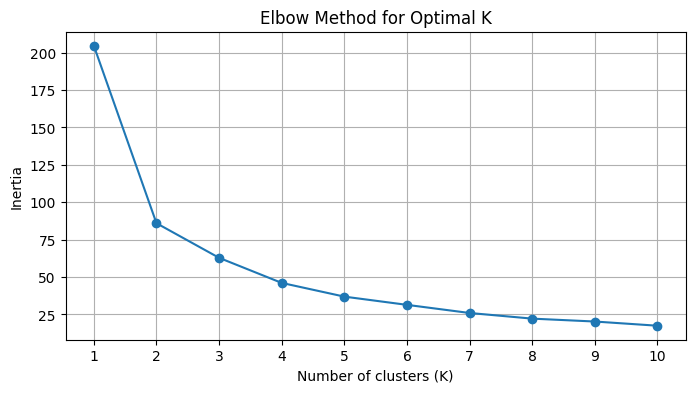

In [ ]:
# Ex 3(b): explore performance for different values of K and discuss how to optimize it.
# Evaluation criterion: inertia -- the within-cluster sum of squared distances between each
# point and its assigned centroid. Inertia can only decrease as K grows (more centroids can
# only get closer to the data), so we can't just pick the K that minimizes it; instead we look
# for the "elbow" -- the K after which adding more clusters stops helping much.

def inertia(X, centroids, labels):
    return np.sum((X - centroids[labels]) ** 2)


# TODO: your code here

# Code made with AI
# Compute inertia for K from 1 to 10
k_values = range(1, 11)
inertias = []
for k in k_values:
    centroids, labels = kmeans(X, k)
    inertias.append(inertia(X, centroids, labels))
# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## (4) Linear classifiers optimization

(4.a) Verify that the gradient of the logistic loss with respect to $w$ is given by $\nabla_w L = \frac{1}{m} X^T(\hat{y} - y)$, where $\hat{y} = \sigma(Xw) = \frac{1}{1 + e^{-Xw}}$ is the model's prediction and $y$ is the target variable.

(4.b) Implement the logistic loss optimization using gradient descent. 

**Note:** `compute_loss` below clips `y_hat` away from exactly 0/1 before taking `log`, since `log(0)` is `-inf` and would blow up the loss (and gradient) once the model becomes very confident — this is a standard numerical-stability trick, not a modeling choice.

In [ ]:
from numpy import gradient
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loss function (Logistic Loss)
def compute_loss(y, y_hat):
    m = y.shape[0]
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)  # avoid log(0), see note above
    loss = -1/m * (np.dot(y, np.log(y_hat)) + np.dot((1 - y), np.log(1 - y_hat)))
    return loss

# Gradient descent function
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = X.shape[0]
    for i in range(iterations):
        z = np.dot(X, theta)
        y_hat = sigmoid(z)
        loss = compute_loss(y, y_hat)
        # Ex 4(b): compute the gradient of the logistic loss w.r.t. theta (see Ex 4(a))
        # TODO: your code here

        #code made with AI
        gradient = (1 / m) * np.dot(X.T, (y_hat - y))
        
        theta -= learning_rate * gradient
        if i % 1000 == 0:
            print(f'Iteration {i}: Loss {loss}')
    return theta

# Main function to train the logistic regression model
def logistic_regression(X, y, learning_rate=0.01, iterations=10000):
    X = np.insert(X, 0, 1, axis=1)  # Add intercept term
    theta = np.zeros(X.shape[1])  # Initialize weights
    theta = gradient_descent(X, y, theta, learning_rate, iterations)
    return theta

# Prediction function
def predict(X, theta):
    X = np.insert(X, 0, 1, axis=1)  # Add intercept term
    probabilities = sigmoid(np.dot(X, theta))
    return probabilities >= 0.5

(4.c) Using the methods defined above, train a logistic regression classifier for the datasets defined above.

(4.d) Discuss the results and compare with the other classifiers.

Iteration 0: Loss 0.6931471805599453
Iteration 1000: Loss 0.33827426783902087
Iteration 2000: Loss 0.33696074499733414
Iteration 3000: Loss 0.33690430333944377
Iteration 4000: Loss 0.33690140286051395
Iteration 5000: Loss 0.33690124814611444
Iteration 6000: Loss 0.3369012398234228
Iteration 7000: Loss 0.33690123937483746
Iteration 8000: Loss 0.3369012393506482
Iteration 9000: Loss 0.3369012393493438
Iteration 10000: Loss 0.33690123934927335
Iteration 11000: Loss 0.3369012393492695
Iteration 12000: Loss 0.3369012393492693
Iteration 13000: Loss 0.3369012393492693
Iteration 14000: Loss 0.3369012393492693
Iteration 0: Loss 0.6931471805599453
Iteration 1000: Loss 0.693113055918991
Iteration 2000: Loss 0.6931130559032695
Iteration 3000: Loss 0.6931130559032694
Iteration 4000: Loss 0.6931130559032695
Iteration 5000: Loss 0.6931130559032695
Iteration 6000: Loss 0.6931130559032695
Iteration 7000: Loss 0.6931130559032695
Iteration 8000: Loss 0.6931130559032695
Iteration 9000: Loss 0.693113055903

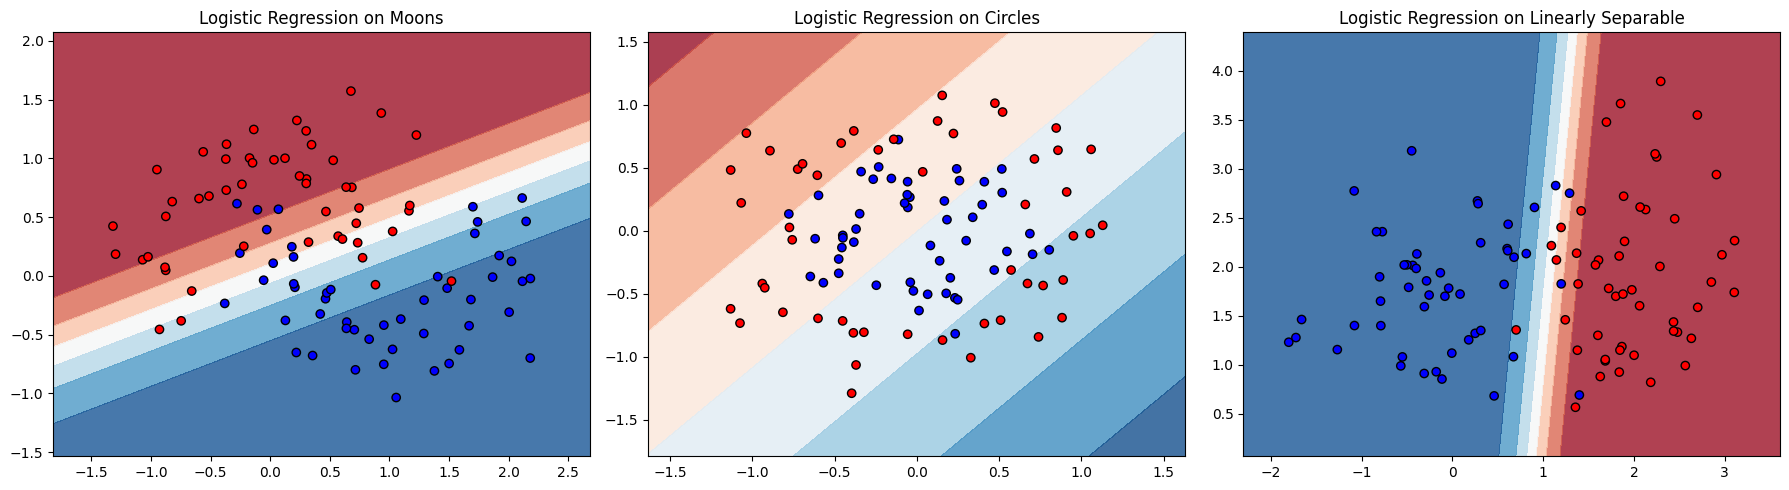

In [ ]:
# Ex 4(c): train a logistic-regression classifier (defined above) on each of the three datasets
# and visualize its decision boundary.
# Tip: reuse the same `datasets` list and `cm`/`cm_bright` colormaps as in the classifier
# comparison figure at the top of the notebook.
# TODO: your code here

#Code made with AI
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dataset_names = ["Moons", "Circles", "Linearly Separable"]
for ax, (X_data, y_data), name in zip(axes, datasets, dataset_names):
    # Train
    theta = logistic_regression(X_data, y_data, learning_rate=0.1, iterations=15000)
    # Grid for decision boundary
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    # Predict over grid
    grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
    Z = sigmoid(np.dot(grid, theta)).reshape(xx.shape)
    # Plot
    ax.contourf(xx, yy, Z, cmap=cm, alpha=0.8)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=cm_bright, edgecolors="k")
    ax.set_title(f"Logistic Regression on {name}")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

## **Ex 4(d): Discussion & Comparison** (AI)
**Linear Decision Boundary:** Logistic regression produces a hyperplane (straight line in 2D) where $w^T x + b = 0$.
**Linearly Separable:** Performs very well, matching Linear SVM.
**Moons & Circles (Non-linear):** Fails because data requires non-linear boundaries. Unlike RBF SVM, Decision Trees, Random Forest, or Neural Networks, linear logistic regression cannot curve around or enclose classes without explicit polynomial feature engineering.